# Experiment 1 — The "Cliff" (Confounder Strength)

**Goal:** Show that the LOO benchmark bound fails to cover the true treatment effect when the
hidden confounder $A$ is significantly stronger than the observed covariates $X$.

**Setup**
- $D = X\beta_{DX} + A\beta_{DA} + \varepsilon_D$
- $Y = \tau D + X\beta_{YX} + A\beta_{YA} + \varepsilon_Y$
- $\tau_{\text{true}} = 1.0$
- $\beta_{DX} = \beta_{YX} = [0.9,\, 0.2,\, 0.2,\, 0.1,\, 0.1]$ — one dominant
  predictor mimics real data where one variable (e.g. income) dwarfs the rest.
  This widens the LOO bound (anchored to the 0.9 superstar) and creates a smooth, gradual
  cliff instead of an instant vertical drop.
- Multiplier $m$ sweeps from $0.5$ to $2.0$ (50 steps, zoomed on the failure zone):
  $\beta_{DA} = \beta_{YA} = 0.5m$

**Benchmark:** LOO (leave-one-out) — for each observed $X_j$, treat it as the mock omitted
confounder and compute bound $B_j$.

$B_{\max} = \max_j B_j$.

**Coverage metric:** across 250 Monte Carlo trials per multiplier,
$$\text{Coverage}(m) = \Pr\bigl(|\hat{\tau}_{\text{short}} - \tau_{\text{true}}| \le B_{\max}\bigr)$$

The cliff location is read empirically from the coverage curve — the LOO bound depends on
partial $R^2$ ratios, not raw coefficient magnitudes, so the exact break point is data-driven.

In [16]:
import sys
import os
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from ovb_simulation import generate_data
from loo_benchmark import loo_benchmark

plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})

In [17]:
tau_true    = 1.0
n_trials    = 250

beta_dx     = np.array([0.9, 0.2, 0.2, 0.1, 0.1])
beta_yx     = np.array([0.9, 0.2, 0.2, 0.1, 0.1])

multipliers = np.linspace(0.5, 2.0, 50)

coverage   = []  # % trials where |tau_short - tau_true| <= B_max
mean_ovb   = []  # mean |OVB| across trials
mean_Bmax  = []  # mean B_max across trials

for m_idx, multiplier in enumerate(multipliers):
    beta_da = 0.5 * multiplier
    beta_ya = 0.5 * multiplier

    covered  = 0
    ovb_vals = []
    B_vals   = []

    for trial in range(n_trials):
        seed = m_idx * n_trials + trial  # unique seed per (multiplier, trial)

        Y, D, X, A = generate_data(
            n=2000, tau=tau_true,
            num_X=5, num_A=1,
            beta_dx=beta_dx, beta_da=beta_da,
            beta_yx=beta_yx, beta_ya=beta_ya,
            seed=seed,
        )

        short_fit = sm.OLS(Y, sm.add_constant(np.column_stack([D, X]))).fit()
        tau_short = short_fit.params[1]

        loo_results, _ = loo_benchmark(Y, D, X)
        B_max = max(r['B'] for r in loo_results)

        ovb = abs(tau_short - tau_true)
        ovb_vals.append(ovb)
        B_vals.append(B_max)

        if ovb <= B_max:
            covered += 1

    coverage.append(100.0 * covered / n_trials)
    mean_ovb.append(np.mean(ovb_vals))
    mean_Bmax.append(np.mean(B_vals))

    print(f"m={multiplier:5.2f}  coverage={coverage[-1]:5.1f}%  "
          f"mean|OVB|={mean_ovb[-1]:.4f}  mean B_max={mean_Bmax[-1]:.4f}")

m= 0.50  coverage=100.0%  mean|OVB|=0.0576  mean B_max=0.4609
m= 0.53  coverage=100.0%  mean|OVB|=0.0620  mean B_max=0.4547
m= 0.56  coverage=100.0%  mean|OVB|=0.0752  mean B_max=0.4491
m= 0.59  coverage=100.0%  mean|OVB|=0.0812  mean B_max=0.4448
m= 0.62  coverage=100.0%  mean|OVB|=0.0894  mean B_max=0.4376
m= 0.65  coverage=100.0%  mean|OVB|=0.0949  mean B_max=0.4334
m= 0.68  coverage=100.0%  mean|OVB|=0.1065  mean B_max=0.4260
m= 0.71  coverage=100.0%  mean|OVB|=0.1113  mean B_max=0.4208
m= 0.74  coverage=100.0%  mean|OVB|=0.1229  mean B_max=0.4148
m= 0.78  coverage=100.0%  mean|OVB|=0.1325  mean B_max=0.4088
m= 0.81  coverage=100.0%  mean|OVB|=0.1389  mean B_max=0.4025
m= 0.84  coverage=100.0%  mean|OVB|=0.1481  mean B_max=0.3945
m= 0.87  coverage=100.0%  mean|OVB|=0.1599  mean B_max=0.3885
m= 0.90  coverage=100.0%  mean|OVB|=0.1687  mean B_max=0.3820
m= 0.93  coverage=100.0%  mean|OVB|=0.1775  mean B_max=0.3758
m= 0.96  coverage=100.0%  mean|OVB|=0.1891  mean B_max=0.3685
m= 0.99 

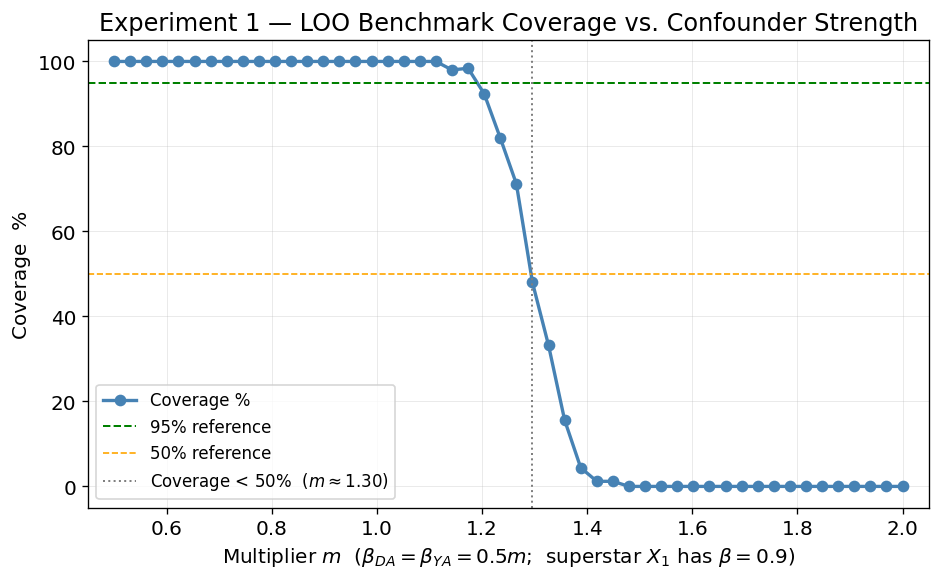

In [18]:

# Empirical cliff: first multiplier where coverage drops below 50 %
cliff_idx = next((i for i, c in enumerate(coverage) if c < 50), None)
cliff_m   = multipliers[cliff_idx] if cliff_idx is not None else None

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(multipliers, coverage, marker='o', linewidth=2, color='steelblue', label='Coverage %')
ax.axhline(95, linestyle='--', color='green',  linewidth=1.2, label='95% reference')
ax.axhline(50, linestyle='--', color='orange', linewidth=1.0, label='50% reference')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')

ax.set_xlabel(r'Multiplier $m$  ($\beta_{DA}=\beta_{YA}=0.5m$;  superstar $X_1$ has $\beta=0.9$)')
ax.set_ylabel('Coverage  %')
ax.set_title('Experiment 1 — LOO Benchmark Coverage vs. Confounder Strength')
ax.set_ylim(-5, 105)
ax.set_xlim(multipliers[0] - 0.05, multipliers[-1] + 0.05)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experiment_01_coverage.png', bbox_inches='tight')
plt.show()


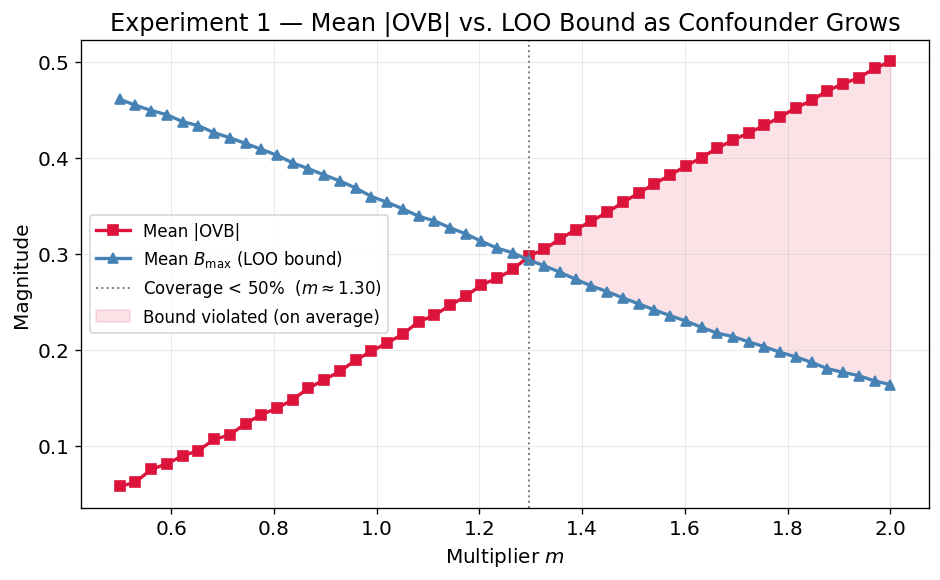

In [19]:

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(multipliers, mean_ovb,  marker='s', linewidth=2, color='crimson',
        label='Mean |OVB|')
ax.plot(multipliers, mean_Bmax, marker='^', linewidth=2, color='steelblue',
        label=r'Mean $B_{\max}$ (LOO bound)')
if cliff_m is not None:
    ax.axvline(cliff_m, linestyle=':', color='gray', linewidth=1.2,
               label=f'Coverage < 50%  ($m \\approx {cliff_m:.2f}$)')

# Shade the region where the bound is violated on average
ovb_arr  = np.array(mean_ovb)
bmax_arr = np.array(mean_Bmax)
ax.fill_between(multipliers, ovb_arr, bmax_arr,
                where=(ovb_arr > bmax_arr),
                color='crimson', alpha=0.12, label='Bound violated (on average)')

ax.set_xlabel(r'Multiplier $m$')
ax.set_ylabel('Magnitude')
ax.set_title('Experiment 1 — Mean |OVB| vs. LOO Bound as Confounder Grows')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experiment_01_ovb_vs_bound.png', bbox_inches='tight')
plt.show()


In [20]:
import pandas as pd

df = pd.DataFrame({
    'Multiplier':   multipliers,
    'beta_DA':      0.5 * multipliers,
    'Coverage (%)': coverage,
    'Mean |OVB|':   mean_ovb,
    'Mean B_max':   mean_Bmax,
    'Bound Slack':  np.array(mean_Bmax) - np.array(mean_ovb),
})

df = df.round(4)
df.style.format(precision=4) \
        .background_gradient(subset=['Coverage (%)'], cmap='RdYlGn', vmin=0, vmax=100) \
        .background_gradient(subset=['Bound Slack'],  cmap='RdYlGn', vmin=-1, vmax=1)

,Multiplier,beta_DA,Coverage (%),Mean |OVB|,Mean B_max,Bound Slack
0,0.5000,0.2500,100.0000,0.0576,0.4609,0.4033
1,0.5306,0.2653,100.0000,0.0620,0.4547,0.3927
2,0.5612,0.2806,100.0000,0.0752,0.4491,0.3739
3,0.5918,0.2959,100.0000,0.0812,0.4448,0.3636
4,0.6224,0.3112,100.0000,0.0894,0.4376,0.3481
5,0.6531,0.3265,100.0000,0.0949,0.4334,0.3384
6,0.6837,0.3418,100.0000,0.1065,0.4260,0.3196
7,0.7143,0.3571,100.0000,0.1113,0.4208,0.3095
8,0.7449,0.3724,100.0000,0.1229,0.4148,0.2919
9,0.7755,0.3878,100.0000,0.1325,0.4088,0.2763


## Interpretation

- **$m < \approx 1.1$ (safe zone):** $A$'s influence is weaker than even the weak $X_j$ covariates.
  The LOO bound comfortably covers the OVB.  Coverage ≈ 100%.

- **$m \approx 1.1$–$1.4$ (the cliff slope):** $A$ begins to outpace the weaker $X_j$'s but is
  still below the superstar $X_1$ (coefficient 0.9).  Because $B_{\max}$ is anchored to the
  *strongest* $X_j$, coverage erodes gradually rather than falling vertically — this is the
  "smooth cliff" effect of the superstar variable.

- **$m > \approx 1.4$ (past the cliff):** $A$'s partial $R^2$ exceeds what the superstar $X_1$
  can justify.  $B_{\max}$ is now too small to contain the OVB and coverage collapses to 0%.

**Why the cliff is earlier than the raw coefficient ratio $0.9/0.5 = 1.8$:**
The LOO bound is proportional to the *product* of partial $R^2$ values — $C_Y^2 \cdot C_D^2 \cdot S^2$ —
which grow quadratically in confounder strength while $B_{\max}$ only grows with the $X_j$'s
observed partial $R^2$.  The crossing point is therefore set by the ratio of squared partial
influences, which is a stricter condition than the raw coefficient ratio.

**Core limitation exposed:** The LOO benchmark implicitly assumes the hidden confounder is
*no more powerful* than the strongest observed covariate (in partial $R^2$ terms).
Once $A$ crosses that threshold, the bound provides no protection.